In [1]:
import os
import re
import lda
import time
import random
import itertools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter
from nltk.stem import SnowballStemmer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import spacy
nlp = spacy.load('en_core_web_md', disable=['parser', 'ner'])  # we use the medium-sized model, optimized for speed

## Fetch narratives

In [2]:
# list of files
narr_files = [
    "gpt-4o-mini_0.0_given_local.json",
    "gpt-4o-mini_0.5_given_local.json",
    "gpt-4o-mini_1.2_given_local.json"
]
narr_dir = "data/narratives/"

def load_json_narratives_to_df(narr_dir, narr_files):
    df_list = [
        format_narrative_df(pd.read_json(os.path.join(narr_dir,file)), file)
        for file in tqdm(narr_files, desc="Loading narrative file")
    ]
    narr_df = pd.concat(df_list, ignore_index=True)

    return narr_df

def format_narrative_df(df, file_name):
    print(f"Formatting: {file_name}")
    df_formatted = df.melt(var_name='profile_id', value_name='text')
    df_formatted['model'] = file_name.split(sep='_')[0]
    df_formatted['temperature'] = float(file_name.split(sep='_')[1])
    df_formatted['scenario'] = file_name.split(sep='_')[2]
    df_formatted['sample'] = df_formatted.groupby('profile_id').cumcount() + 1

    return df_formatted

narrs = load_json_narratives_to_df(narr_dir, narr_files)

Loading narrative file:  33%|███▎      | 1/3 [00:00<00:01,  1.18it/s]

Formatting: gpt-4o-mini_0.0_given_local.json


Loading narrative file:  67%|██████▋   | 2/3 [00:01<00:00,  1.40it/s]

Formatting: gpt-4o-mini_0.5_given_local.json


Loading narrative file: 100%|██████████| 3/3 [00:02<00:00,  1.39it/s]

Formatting: gpt-4o-mini_1.2_given_local.json


In [3]:
narrs

,profile_id,text,model,temperature,scenario,sample
0,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,1
1,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,2
2,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,3
3,1,"As the sun began to rise over the barracks, Pr...",gpt-4o-mini,0.0,given,4
4,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,5
...,...,...,...,...,...,...
63355,1056,Samantha Caldwell stared out the window of her...,gpt-4o-mini,1.2,given,16
63356,1056,The sun slipped behind the horizon as Ava Morg...,gpt-4o-mini,1.2,given,17
63357,1056,Standing on the uneven wooden deck of her mode...,gpt-4o-mini,1.2,given,18
63358,1056,"At the edge of dawn, Clara stands by her kitch...",gpt-4o-mini,1.2,given,19


## Preprocessing

### CountVectorizer

In [ ]:
count_vectorizer = CountVectorizer(lowercase=True,                       # convert all characters to lower-case
                                   strip_accents="ascii",                # remove non-ascii characters (WARNING: this is dangerous in Romance languages)
                                   stop_words="english",                 # remove stopwords from a built-in list. We can also provide our own list
                                   ngram_range=(1, 1),                   # generate only unigrams TODO
                                   analyzer="word",                      # build matrix at the word-level TODO
                                   max_df=0.7,                           # ignore tokens that have a higher document frequency (can be int or percent)
                                   min_df=100,                           # ignore tokens that have a lower document frequency (can be int or percent)
                                   matetextt_features=None,                    # we could impose a maximum number of vocabulary terms
                                   )     

In [37]:
doc_term_matrix = count_vectorizer.fit_transform(narrs["text"])
print(f"Document-term matrix created with shape: {doc_term_matrix.shape}") 

Document-term matrix created with shape: (63360, 5587)


In [38]:
# we can explore the vocaburaly as pairs of (word, position in matrix)
random.sample(list(count_vectorizer.vocabulary_.items()),10)

[('sleek', 4460),
 ('maneuvering', 2939),
 ('aspires', 269),
 ('kitchenware', 2675),
 ('relied', 3933),
 ('strange', 4712),
 ('grounding', 2171),
 ('lunches', 2905),
 ('establish', 1654),
 ('rekindling', 3924)]

In [47]:
feature_names = count_vectorizer.get_feature_names_out()
# Sum the term frequencies across all documents
term_frequencies = np.array(doc_term_matrix.sum(axis=0)).flatten()
# Create a sorted list of (term, frequency) tuples
sorted_terms = sorted(zip(feature_names, term_frequencies), key=lambda x: x[1], reverse=True)
# Display the most frequent terms
print("Most frequent terms:")
for term, freq in sorted_terms[:50]:
    print(f"{term}: {freq}")

Most frequent terms:
maria: 57069
dreams: 54754
work: 51217
just: 49508
challenges: 45737
education: 44198
weight: 42147
sun: 41570
like: 40344
years: 40339
school: 37274
family: 37158
future: 35922
laughter: 35871
resilience: 34842
hope: 33885
community: 32440
children: 31758
aspirations: 31574
solace: 30401
heart: 29020
filled: 28813
despite: 28791
shared: 28333
days: 28066
journey: 27970
world: 27916
home: 26229
moments: 25963
spent: 25444
quiet: 24877
morning: 24385
time: 24123
passion: 24026
local: 23646
love: 23194
coffee: 21920
job: 21879
began: 20875
late: 20251
step: 20188
dreamed: 19637
clara: 19495
single: 19422
town: 19241
purpose: 19069
determination: 18842
determined: 18465
left: 18265
path: 18206


### Custom preprocessing

In [ ]:
# remove popular bigrams and trigrams


# Extract bigrams from all docs
bigrams = list(itertools.chain(*[list(ngrams(doc.split(), 2)) for doc in docs]))

# Count occurrences
bigram_counts = Counter(bigrams)

# Remove bigrams appearing in >50% of documents
threshold = len(docs) * 0.5
common_bigrams = {bigram for bigram, count in bigram_counts.items() if count > threshold}


In [72]:
user_defined_stop_words = { # words that we have noticed are characteristic to the narrative style
    "sun",
    "day",
    "path",
    "night",
    "coffee",
    "morning",
    "horizon",
    "life",
    "journey"
}
nlp.Defaults.stop_words |= user_defined_stop_words  # combine default spaCy stop words with user-defined stop-words

# we also them as stopwords in the pipeline
for word in user_defined_stop_words:
    lexeme = nlp.vocab[word]  # Get the word's lexeme object
    lexeme.is_stop = True  # Mark it as a stopword

stemmer = SnowballStemmer("english")

def clean_text(text):
    return re.sub(r'[^a-z\s]', '', text.lower()) # remove everything except lowercase letters and spaces

def batch_preprocess_and_tokenize_lemmatizing(texts, batch_size=200):
    processed_texts = []
    cleaned_texts = [clean_text(text) for text in texts]

    for doc in tqdm(nlp.pipe(cleaned_texts, batch_size=batch_size, n_process=2), total=len(texts), desc="Processing"):
        tokens = [
            token.lemma_ for token in doc if not token.is_punct and not token.is_space and not token.is_stop and not token.is_digit
            ]
        processed_texts.append(" ".join(tokens))  # Join back into a string

    return processed_texts

def batch_preprocess_and_tokenize_stemming(texts, batch_size=200):
    processed_texts = []
    cleaned_texts = [clean_text(text) for text in texts]

    for doc in tqdm(nlp.pipe(cleaned_texts, batch_size=batch_size, n_process=2), total=len(texts), desc="Processing"):
        tokens = [stemmer.stem(token.text) for token in doc if not token.is_punct and not token.is_space and not token.is_stop and not token.is_digit]
        processed_texts.append(" ".join(tokens))  # Join back into a string

    return processed_texts

In [73]:
start_time = time.time()
narrs["tokens_lemm"] = batch_preprocess_and_tokenize_lemmatizing(narrs["text"])
print(f"Custom preprocessing with lemmatization applied to dataframe in {time.time()-start_time:.4f} seconds")

Processing: 100%|██████████| 63360/63360 [13:26<00:00, 78.56it/s] 

Custom preprocessing with lemmatization applied to dataframe in 808.6105 seconds


In [74]:
start_time = time.time()
narrs["tokens_stem"] = batch_preprocess_and_tokenize_stemming(narrs["text"])
print(f"Custom preprocessing with stemming applied to dataframe in {time.time()-start_time:.4f} seconds")

Processing: 100%|██████████| 63360/63360 [14:40<00:00, 71.99it/s] 

Custom preprocessing with stemming applied to dataframe in 882.3503 seconds


In [75]:
narrs.head(10)

,profile_id,text,model,temperature,scenario,sample,tokens_lemm,tokens_stem
0,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,1,begin rise barrack marcus lace boot familiar s...,began rise barrack marcus lace boot familiar s...
1,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,2,begin rise barrack marcus lace boot familiar s...,began rise barrack marcus lace boot familiar s...
2,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,3,begin rise barrack marcus lace boot familiar s...,began rise barrack marcus lace boot familiar s...
3,1,"As the sun began to rise over the barracks, Pr...",gpt-4o-mini,0.0,given,4,begin rise barrack private class daniel reyes ...,began rise barrack privat class daniel rey lac...
4,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,5,begin rise barrack marcus lace boot familiar s...,began rise barrack marcus lace boot familiar s...
5,1,"As the sun began to rise over the barracks, Pr...",gpt-4o-mini,0.0,given,6,begin rise barrack private class daniel reyes ...,began rise barrack privat class daniel rey lac...
6,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,7,begin rise barrack marcus lace boot familiar s...,began rise barrack marcus lace boot familiar s...
7,1,"As the sun began to rise over the barracks, Pr...",gpt-4o-mini,0.0,given,8,begin rise barrack private class daniel reyes ...,began rise barrack privat class daniel rey lac...
8,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,9,begin rise barrack marcus lace boot familiar s...,began rise barrack marcus lace boot familiar s...
9,1,"As the sun began to rise over the barracks, Ma...",gpt-4o-mini,0.0,given,10,begin rise barrack marcus lace boot familiar s...,began rise barrack marcus lace boot familiar s...


In [113]:
count_vect_1 = CountVectorizer(
    max_df=0.6,
    min_df=200,
    max_features=None
)  

tfidf_vect_1 = TfidfVectorizer(
    max_df=0.6,
    min_df=200,
    max_features=None,
    sublinear_tf=True,
    smooth_idf=False
)

count_vect_2 = CountVectorizer(
    max_df=0.7,
    min_df=200,
    max_features=None
)  

tfidf_vect_2 = TfidfVectorizer(
    max_df=0.7,
    min_df=200,
    max_features=None
)

In [114]:
start_time = time.time()
count_lemm = count_vect_1.fit_transform(narrs["tokens_lemm"])
print(f"Count vectorizer applied to lemmatized text in {time.time()-start_time:.4f} seconds")
print(f"Document-term matrix created with shape: {count_lemm.shape}\n") 

start_time = time.time()
tfidf_lemm = tfidf_vect_1.fit_transform(narrs["tokens_lemm"])
print(f"Tf-idf vectorizer applied to lemmatized text in {time.time()-start_time:.4f} seconds")
print(f"Document-term matrix created with shape: {tfidf_lemm.shape}\n") 

start_time = time.time()
count_stem = count_vect_2.fit_transform(narrs["tokens_stem"])
print(f"Count vectorizer applied to stemmed text in {time.time()-start_time:.4f} seconds")
print(f"Document-term matrix created with shape: {count_stem.shape}\n") 

start_time = time.time()
tfidf_stem = tfidf_vect_2.fit_transform(narrs["tokens_stem"])
print(f"Tf-idf vectorizer applied to stemmed text in {time.time()-start_time:.4f} seconds")
print(f"Document-term matrix created with shape: {tfidf_stem.shape}") 

Count vectorizer applied to lemmatized text in 6.3135 seconds
Document-term matrix created with shape: (63360, 3045)

Tf-idf vectorizer applied to lemmatized text in 6.8830 seconds
Document-term matrix created with shape: (63360, 3045)



In [111]:
def most_freq_terms(X, vectorizer, k=10):  
  feature_names = vectorizer.get_feature_names_out()
  # Sum the term frequencies across all documents
  term_frequencies = np.array(X.sum(axis=0)).flatten()
  # Create a sorted list of (term, frequency) tuples
  sorted_terms = sorted(zip(feature_names, term_frequencies), key=lambda x: x[1], reverse=True)
  terms = [term for term, freq in sorted_terms[:k]]
  # return only the k most frequent terms, not their frequencies
  return terms

vectorizers = [count_vect_1, tfidf_vect_1, count_vect_2, tfidf_vect_2]
doc_term_matrices = [count_lemm, tfidf_lemm, count_stem, tfidf_stem]

term_df_list = []
columns = ["CountVect_lemm", "Tfidf_lemm", "CountVect_stem", "Tfidf_stem"]

for i, (vect, X) in enumerate(zip(vectorizers, doc_term_matrices)):
  most_freq_terms_list = most_freq_terms(X, vect, k=50)
  term_df = pd.DataFrame(most_freq_terms_list, columns=[columns[i]])
  term_df_list.append(term_df)

term_df = pd.concat(term_df_list, axis=1)
term_df


,CountVect_lemm,Tfidf_lemm,CountVect_stem,Tfidf_stem
0,maria,maria,work,maria
1,education,education,maria,work
2,share,family,found,found
3,year,share,hope,clara
4,family,year,remind,famili
5,like,child,educ,children
6,school,like,aspir,educ
7,future,school,famili,hope
8,laughter,future,share,remind
9,aspiration,fill,weight,share


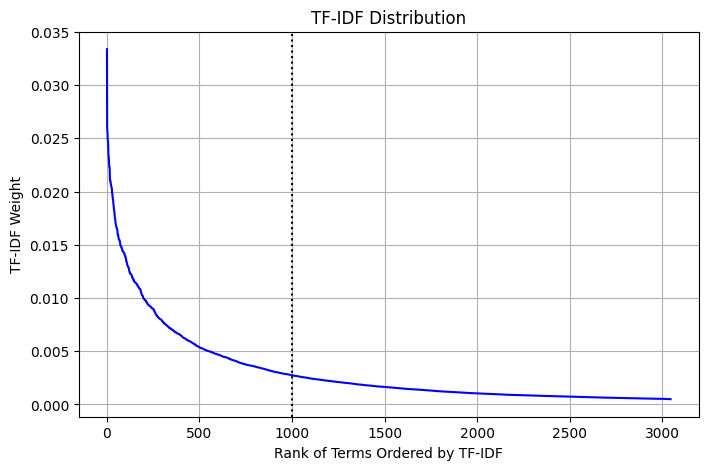

In [116]:
tfidf_scores = np.mean(tfidf_lemm.toarray(), axis=0)  # Mean score across all docs
sorted_indices = np.argsort(tfidf_scores)[::-1]
sorted_scores = tfidf_scores[sorted_indices]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(sorted_scores) + 1), sorted_scores, color="blue")
plt.xlabel("Rank of Terms Ordered by TF-IDF")
plt.ylabel("TF-IDF Weight")
plt.title("TF-IDF Distribution")
plt.grid(True)

# Add a vertical line at a specific rank
plt.axvline(x=1000, color="black", linestyle="dotted")

plt.show()

## LDA

In [98]:
model = lda.LDA(n_topics=25, n_iter=2000, random_state=1)

In [117]:
model.fit(count_lemm)

INFO:lda:n_documents: 63360
INFO:lda:vocab_size: 3045
INFO:lda:n_words: 7333820
INFO:lda:n_topics: 25
INFO:lda:n_iter: 2000
INFO:lda:<0> log likelihood: -79771209
INFO:lda:<10> log likelihood: -64413115
INFO:lda:<20> log likelihood: -59064532
INFO:lda:<30> log likelihood: -57804026
INFO:lda:<40> log likelihood: -57230443
INFO:lda:<50> log likelihood: -56930207
INFO:lda:<60> log likelihood: -56759777
INFO:lda:<70> log likelihood: -56618396
INFO:lda:<80> log likelihood: -56496385
INFO:lda:<90> log likelihood: -56413641
INFO:lda:<100> log likelihood: -56351299
INFO:lda:<110> log likelihood: -56307778
INFO:lda:<120> log likelihood: -56274324
INFO:lda:<130> log likelihood: -56236277


KeyboardInterrupt: 

In [ ]:
n_top_words = 10

for i, topic_dist in enumerate(model.topic_word_):
  topic_words = np.array(list(count_vect.vocabulary_.keys()))[np.argsort(topic_dist)][:-(n_top_words+1):-1]
  print('Topic {}: {}'.format(i+1, ' '.join(topic_words)))

Topic 1: tapping clear entwine sketch grueling difficult dew sergeant hesitant water
Topic 2: essential relationship dew chain lot favorite difficult notice tractor software
Topic 3: sound thank shield include interrupt rekindle dew bitter difficult forward
Topic 4: educate entwine gig sustainable include significant math swing vein dog
Topic 5: network making truck break 36 day closing knack cherished wait
Topic 6: rent gender sketch street retreat eager sell clean day 43
Topic 7: human symbol eager ray draw thank truly shopping sustainable licensed
Topic 8: expression confident gap intersection volunteer sweetheart discussion sheet recovery vein
Topic 9: writing failure unfurl margin making light traditionally door bite hurried
Topic 10: movement web uplift silent 36 planting insecurity practicality impactful making
Topic 11: coding tug competition pitch double pepper antiseptic dog widow bitter
Topic 12: refuge vibrancy wander antiseptic passion sheet strew thing medical pitch
Topic